<a href="https://colab.research.google.com/github/therealcaesar-si/EMSC2010-W10-L1-u7567593/blob/main/EMSC2010_W10_L1_NB4_u7567593.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB4

Use this notebook to process the Japanese cherry blossoms data and see if you can find a pattern in the long term data.

The excel data file ```blossom_doy.xlsx``` contains two variables:


1.   ```year```: The year of the cherry bloom.
2.   ```doy```: The day of the year of the first cherry bloom (where day 0 corresponds to January 1)

Don't forget to use the code in ```EMSC2010-W10-L1-NB2``` and ```EMSC2010-W10-L1-NB3``` as a template for this problem.



In [3]:
# ADD YOUR CODE HERE

import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [5]:
file = 'blossom_doy.xlsx' #define the name of the data file
df = pd.read_excel(file) #read the file into a dataframe
df.head() #show the dataframe header

,year,doy
0,812,92
1,815,105
2,831,96
3,851,108
4,853,104


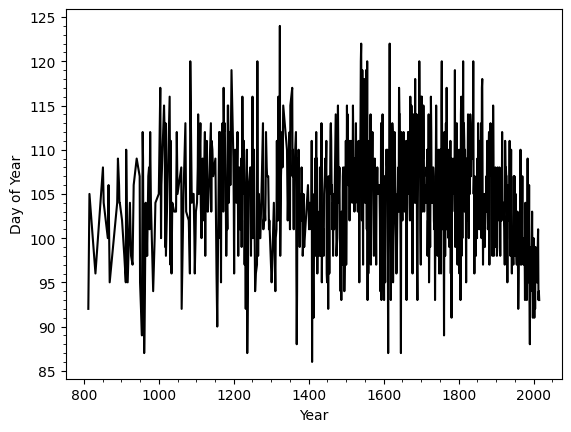

In [7]:
year = df['year'].values #get the year data as a numpy array
doy = df['doy'].values #get the doy data as a numpy array
#plot it
plt.plot(year,doy,'k') #plot the data
plt.xlabel('Year') #label the x-axis
plt.ylabel('Day of Year') #label the y-axis
plt.minorticks_on() #add minor ticks to the plot
#plt.ylim(bottom=0) #limit the y-axis
#plt.xlim(left=0) #limit the x-axis

In [28]:
order = 15 #set the polynomial order
pp = np.polyfit(year,doy,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

/tmp/ipykernel_5601/4102975907.py:2: RankWarning: Polyfit may be poorly conditioned
  pp = np.polyfit(year,doy,order) #fit the polynomial, pp will contain the polynomial coefficients


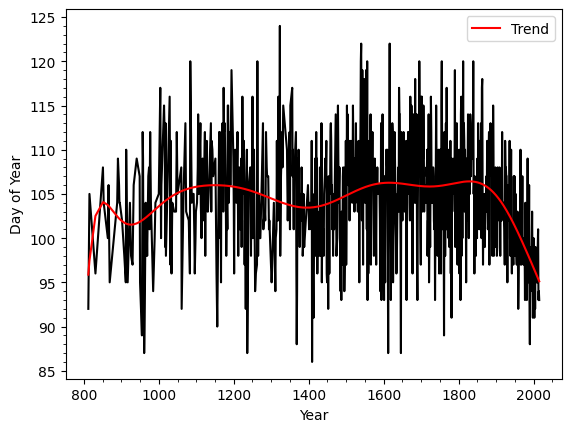

In [29]:
plt.plot(year,doy,'k') #plot the data
plt.plot(year,trend,'r',label='Trend') #plot the trend
plt.legend()
plt.xlabel('Year') #label the x-axis
plt.ylabel('Day of Year') #label the y-axis
plt.minorticks_on() #add minor ticks to the plot

In [9]:
# define the moving average function
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [18]:
w = 33 #length of the moving average
year_s = moving_average(year, w) #process the year
doy_s = moving_average(doy, w) #process the doy

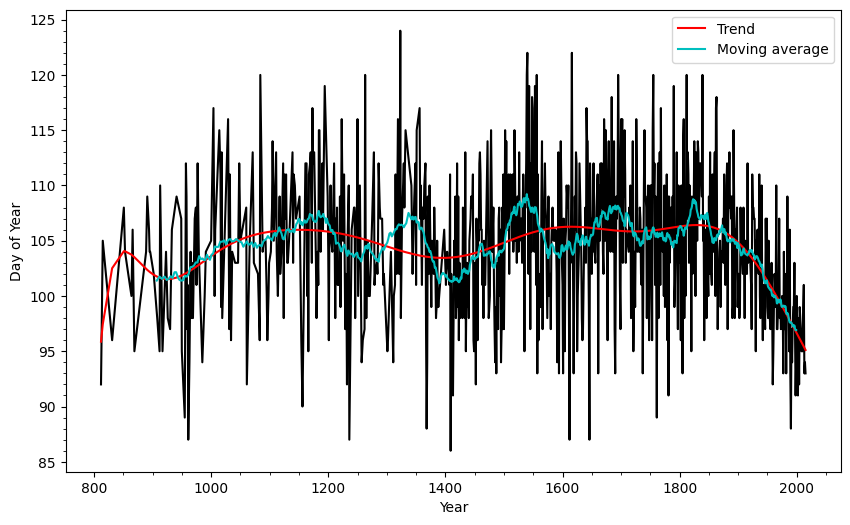

In [30]:
plt.figure(figsize=(10,6))
plt.plot(year,doy,'k') #plot the data
plt.plot(year,trend,'r',label='Trend') #plot the trend
plt.plot(year_s,doy_s,'c',label='Moving average') #plot the moving average
plt.xlabel('Year') #label the x-axis
plt.ylabel('Day of Year') #label the y-axis
plt.minorticks_on() #add minor ticks to the plot
plt.legend() #add a legend to the plot
#plt.ylim(bottom=0) #limit the y-axis
#plt.xlim(left=0) #limit the x-axis